# 内輪向け機械学習コンペ サンプル ノートブック

## ライブラリをインポート

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as LR
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error as MSE

## コンペ配布データ読み込み

### 学習用データ読み込み

In [2]:
train_df = pd.read_csv(f"./data/train.csv")

In [3]:
train_df

,id,temperature,sunshine_h,humidity,ice_sales
0,1,23.2,6.2,56.5,324
1,2,31.3,5.2,69.0,640
2,3,28.2,3.9,80.6,306
3,4,26.4,6.9,75.6,477
4,5,20.2,6.1,78.2,267
...,...,...,...,...,...
495,496,22.9,2.5,73.4,77
496,497,26.2,7.5,71.7,573
497,498,19.1,2.8,66.2,31
498,499,31.6,7.7,63.3,789


### 評価用データ読み込み

In [4]:
test_df = pd.read_csv(f"./data/test.csv")

In [5]:
test_df

,id,temperature,sunshine_h,humidity
0,544,27.7,4.5,76.6
1,516,27.5,4.4,65.0
2,772,36.4,10.0,47.5
3,638,23.6,6.3,77.2
4,715,37.0,9.5,37.4
...,...,...,...,...
295,702,35.5,9.0,31.6
296,669,37.2,11.3,33.8
297,686,38.2,10.0,34.8
298,536,25.1,3.2,74.9


### サンプル投稿ファイル読み込み

In [6]:
submit = pd.read_csv(f"./data/sample_submission.csv")

In [7]:
submit

,id,ice_sales
0,544,0
1,516,0
2,772,0
3,638,0
4,715,0
...,...,...
295,702,0
296,669,0
297,686,0
298,536,0


## 前処理

### 説明変数、目的変数に分割

In [8]:
features = ["temperature", "sunshine_h", "humidity"]

In [9]:
X = train_df[features]
y = train_df["ice_sales"]

In [10]:
X

,temperature,sunshine_h,humidity
0,23.2,6.2,56.5
1,31.3,5.2,69.0
2,28.2,3.9,80.6
3,26.4,6.9,75.6
4,20.2,6.1,78.2
...,...,...,...
495,22.9,2.5,73.4
496,26.2,7.5,71.7
497,19.1,2.8,66.2
498,31.6,7.7,63.3


In [11]:
y

0      324
1      640
2      306
3      477
4      267
      ... 
495     77
496    573
497     31
498    789
499    568
Name: ice_sales, Length: 500, dtype: int64

In [12]:
X_test = test_df[features]

In [13]:
X_test

,temperature,sunshine_h,humidity
0,27.7,4.5,76.6
1,27.5,4.4,65.0
2,36.4,10.0,47.5
3,23.6,6.3,77.2
4,37.0,9.5,37.4
...,...,...,...
295,35.5,9.0,31.6
296,37.2,11.3,33.8
297,38.2,10.0,34.8
298,25.1,3.2,74.9


### 訓練用データ、検証用データに分割

In [14]:
X_train, X_eval, y_train, y_eval = train_test_split(X, y)

In [15]:
X_train

,temperature,sunshine_h,humidity
281,22.7,5.3,74.6
246,24.0,4.3,54.6
495,22.9,2.5,73.4
31,20.4,8.0,70.9
107,28.6,4.2,76.5
...,...,...,...
209,20.3,6.1,84.9
490,24.4,6.8,58.3
266,27.8,6.6,63.7
428,22.9,5.8,72.4


In [16]:
y_train

281    294
246    236
495     77
31     379
107    362
      ... 
209    208
490    485
266    616
428    295
432    641
Name: ice_sales, Length: 375, dtype: int64

In [17]:
X_eval

,temperature,sunshine_h,humidity
200,27.0,5.2,76.5
144,22.0,2.7,59.3
267,27.8,7.3,66.8
27,25.2,3.6,79.6
450,28.9,5.6,67.4
...,...,...,...
487,21.9,4.6,74.3
463,26.2,4.3,73.0
271,29.3,7.1,80.1
73,29.4,5.7,50.6


In [18]:
y_eval

200    403
144    104
267    592
27     214
450    514
      ... 
487    216
463    298
271    659
73     647
331    492
Name: ice_sales, Length: 125, dtype: int64

## モデルを訓練

In [19]:
model = LR()

In [20]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 訓練済みモデルによる予測（検証用データ）

In [21]:
y_pred_eval = model.predict(X_eval)

In [22]:
y_pred_eval

array([418.28397409,  86.09943767, 620.71184579, 230.28478605,
       529.01147772,   4.65780762,  41.95551088, 640.57088774,
       271.7568635 , 445.4056192 , 527.67244665, 373.17293785,
        23.88873169,  77.88208257,  14.14381371, 174.08783295,
       316.15724143, 329.18562593, 396.95413746, 442.07311304,
       513.174073  ,   1.77792478, 500.11025037, 386.59543732,
       -24.92782324, 490.42893539, 262.70673875, 364.35786284,
       510.09395654, 240.85686925, 130.7448166 , 147.36202934,
       394.00419752, 600.68579928,  15.53334245, 243.97936047,
       415.99395353, 615.86839289, 245.85842227, 253.77583654,
        79.05157699, 265.17140423, 160.15875945, 358.89723243,
       385.95416999, 508.89690562, 319.54386825, 146.46442631,
       256.91167437, 140.93152973, 340.0564332 , 516.81154653,
        24.21819683, 148.98949661,  12.01089057, 325.56346682,
       729.77971355, 206.59553788, 249.73100327, 401.50122843,
       626.96999129, 390.41235466, 445.68131716, -19.02

予測精度の可視化

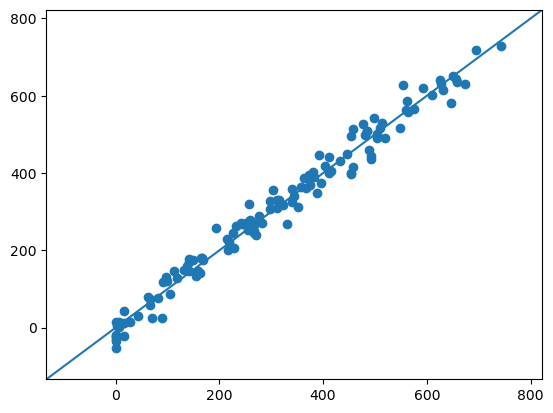

In [23]:
plt.scatter(y_eval, y_pred_eval)

y_eval_min = np.min(y_eval)
y_eval_max = np.max(y_eval)
y_pred_eval_min = np.min(y_pred_eval)
y_pred_eval_max = np.max(y_pred_eval)
y_min = np.minimum(y_eval_min, y_pred_eval_min)
y_max = np.maximum(y_eval_max, y_pred_eval_max)

y_range = y_max - y_min

lim_min = y_min - (y_range * 0.1)
lim_max = y_max + (y_range * 0.1)

plt.xlim([lim_min, lim_max])
plt.ylim([lim_min, lim_max])

plt.plot([lim_min, lim_max], [lim_min, lim_max])

plt.show()

In [24]:
mse_eval = MSE(y_eval, y_pred_eval)
rmse_eval = np.sqrt(mse_eval)

In [25]:
f"{rmse_eval=}"

'rmse_eval=np.float64(28.29549079458057)'

## 訓練済みモデルによる予測（評価用データ）

In [26]:
y_pred_test = model.predict(X_test)

In [27]:
len(y_pred_test)

300

## 採点用投稿ファイル作成

In [28]:
submit["ice_sales"] = y_pred_test

In [29]:
submit

,id,ice_sales
0,544,389.263042
1,516,394.172871
2,772,1152.636424
3,638,383.394950
4,715,1152.306959
...,...,...
295,702,1072.617851
296,669,1301.258131
297,686,1235.691495
298,536,204.446750


In [30]:
submit.to_csv("submit.csv", index=False)